In [78]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
from scipy import stats

In [2]:
df=pd.read_csv(r"C:\Users\GR0012AU\Downloads\concrete_data.csv")

In [3]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [4]:
x=df.drop(["Strength"],axis=1)
y=df["Strength"]

In [5]:
x

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360
...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28


In [6]:
y

0       79.99
1       61.89
2       40.27
3       41.05
4       44.30
        ...  
1025    44.28
1026    31.18
1027    23.70
1028    32.77
1029    32.40
Name: Strength, Length: 1030, dtype: float64

In [38]:
from sklearn.model_selection import train_test_split

In [39]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

In [41]:
LR=LinearRegression()
# DTR=DecisionTreeRegressor()

In [42]:
LR.fit(x_train,y_train)
# DTC.fit(x_train,y_train)

LinearRegression()

In [43]:
y_pred=LR.predict(x_test)

In [44]:
from sklearn.metrics import r2_score

In [45]:
r2=r2_score(y_pred,y_test)

In [46]:
print(r2)

0.42317047978909783


In [47]:
from sklearn.model_selection import cross_val_score

In [49]:
lr=LinearRegression()
np.mean(cross_val_score(lr,x,y,scoring="r2"))

0.46099404916628633

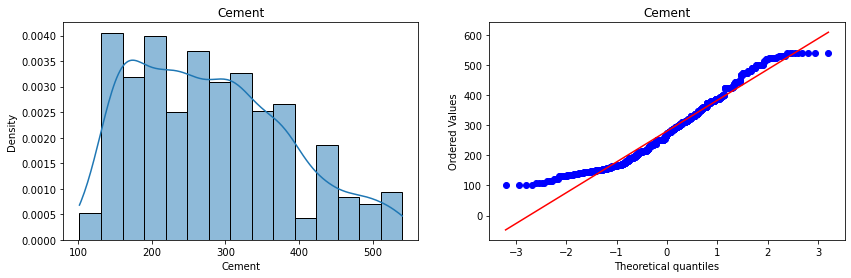

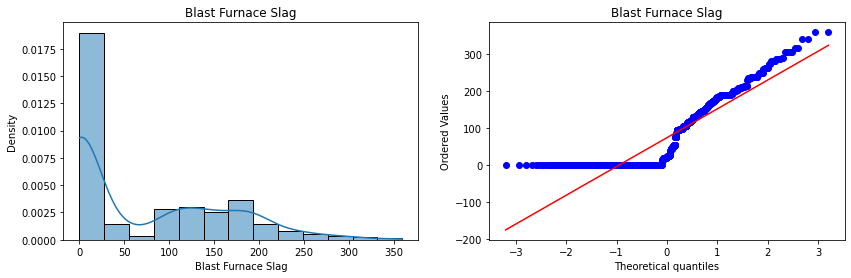

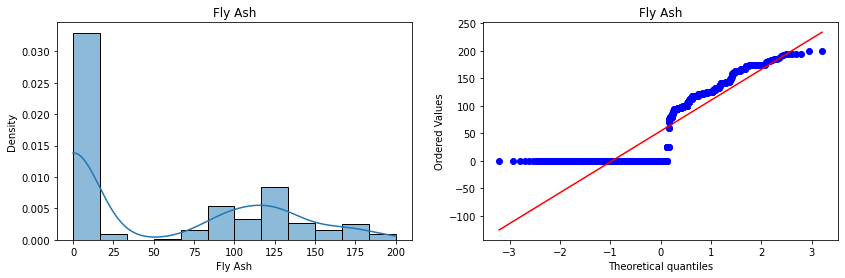

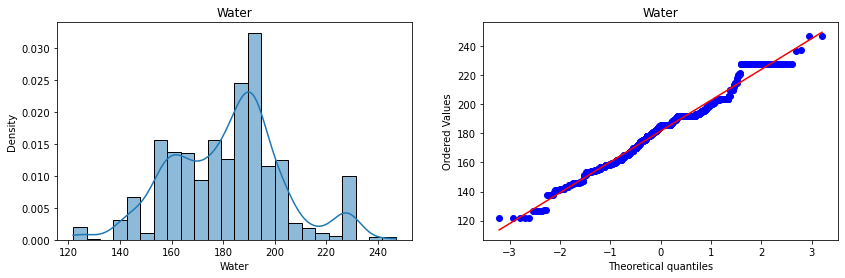

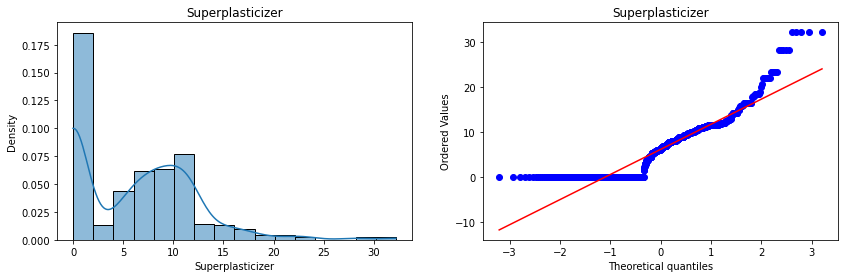

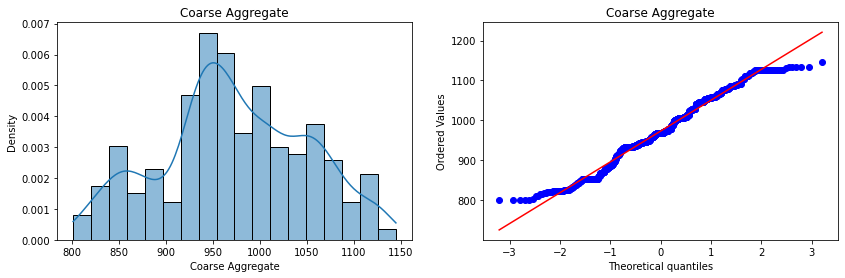

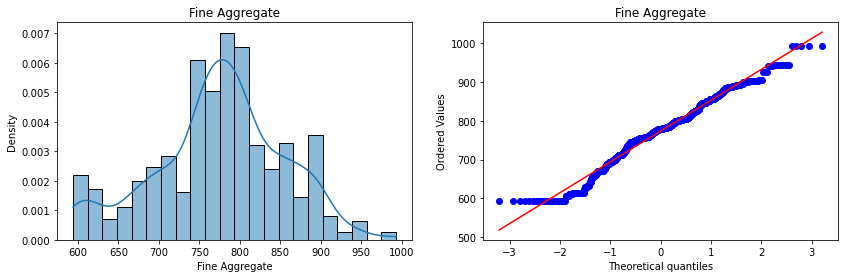

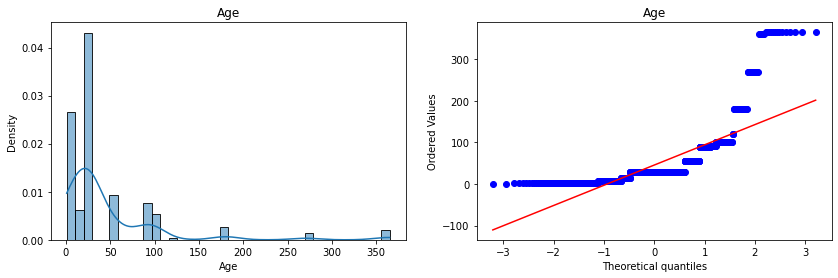

In [52]:
for column in x.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x[column],stat="density",kde=True)
    plt.title(column)
    plt.subplot(1,2,2)
    stats.probplot(x[column],dist="norm",plot=plt)
    plt.title(column)

In [53]:
from sklearn.preprocessing import PowerTransformer

In [57]:
pk=PowerTransformer(method="box-cox")
# x_train_transform=pk.fit_transform(x_train+0.00001)
# x_test_transform=pk.transform(x_test+0.00001)

In [64]:
x_tranform=pk.fit_transform(x+0.00001)
pk.lambdas_

array([ 0.17227106,  0.02805207, -0.03707163,  0.80956818,  0.11497859,
        1.12916789,  1.82962501,  0.04897486])

In [65]:
pd.DataFrame({"columns":x.columns,"box-cox_lambdas":pk.lambdas_})

,columns,box-cox_lambdas
0,Cement,0.172271
1,Blast Furnace Slag,0.028052
2,Fly Ash,-0.037072
3,Water,0.809568
4,Superplasticizer,0.114979
5,Coarse Aggregate,1.129168
6,Fine Aggregate,1.829625
7,Age,0.048975


In [70]:
x_transform_dataset=pd.DataFrame(x_tranform,columns=x.columns)

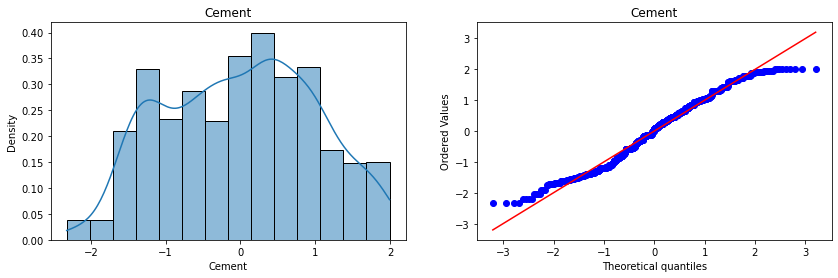

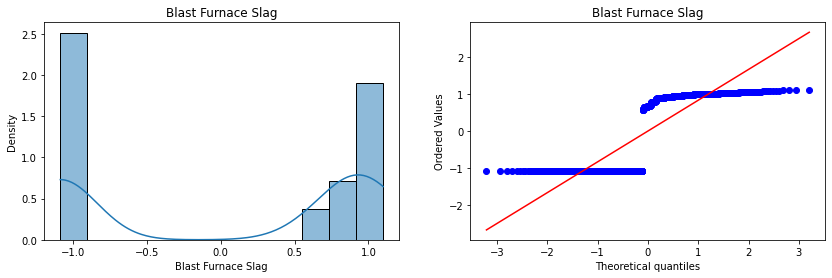

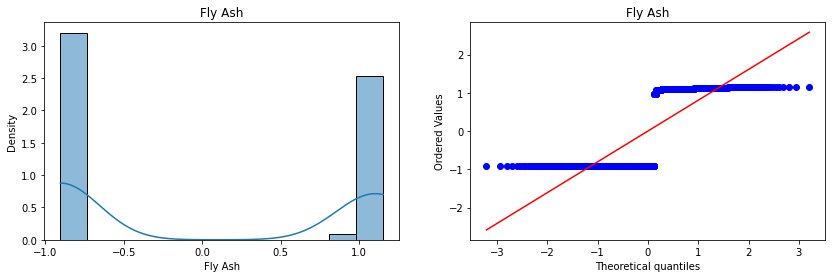

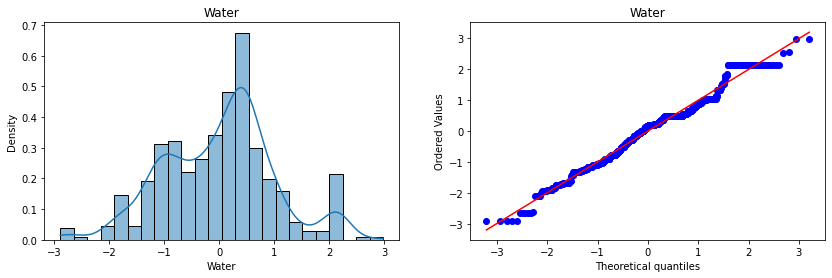

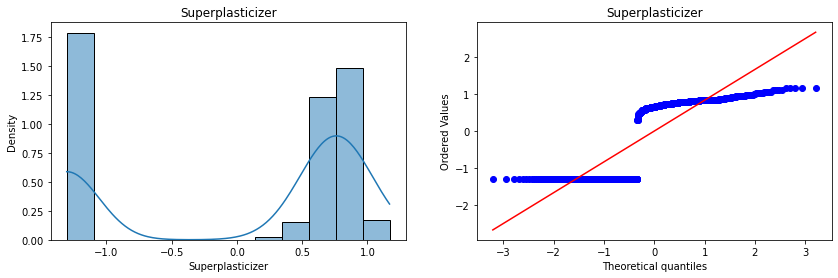

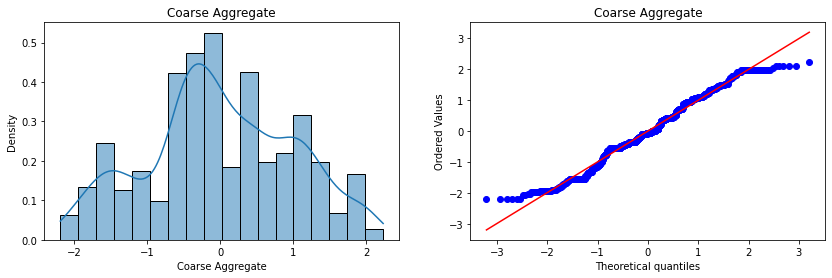

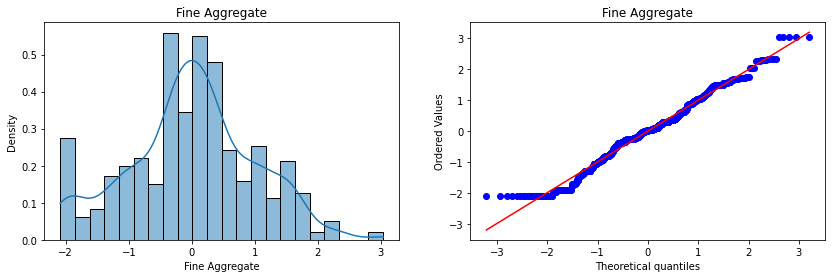

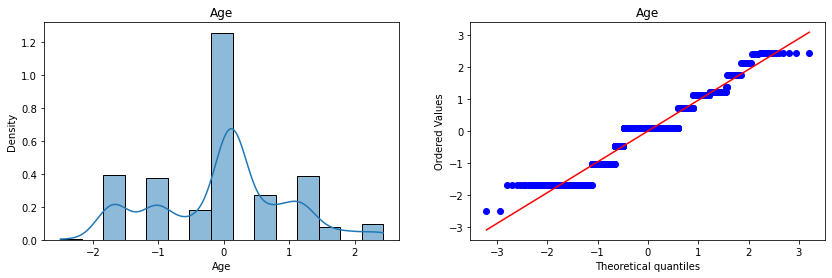

In [71]:
for column in x.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x_transform_dataset[column],stat="density",kde=True)
    plt.title(column)
    plt.subplot(1,2,2)
    stats.probplot(x_transform_dataset[column],dist="norm",plot=plt)
    plt.title(column)

In [72]:
lr_box_cox=LinearRegression()
np.mean(cross_val_score(lr_box_cox,x_transform_dataset,y,scoring="r2"))

0.6668489653763874

In [73]:
pt=PowerTransformer()
x_yeo_johnson=pt.fit_transform(x)

In [74]:
lr_yeo_johnson=LinearRegression()
np.mean(cross_val_score(lr_yeo_johnson,x_yeo_johnson,y,scoring="r2"))

0.6834625134285744

In [76]:
x_yeo_johnson_dataset=pd.DataFrame(x_yeo_johnson,columns=x.columns)

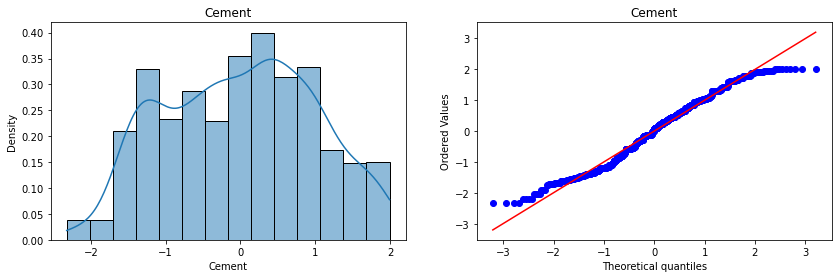

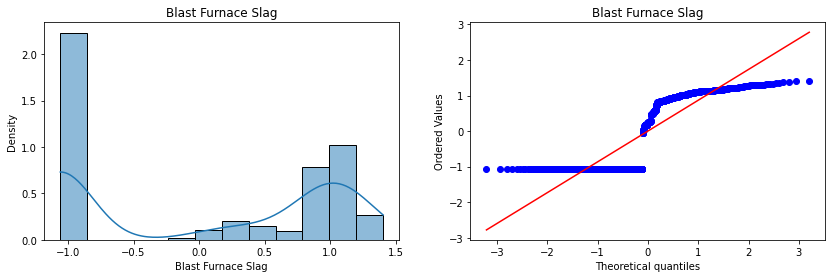

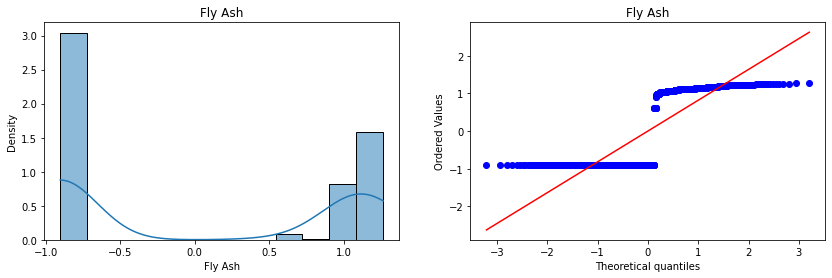

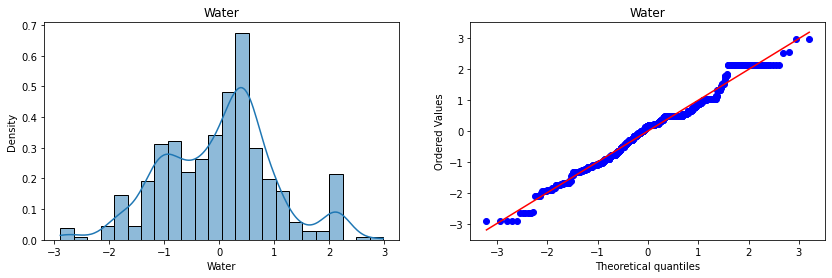

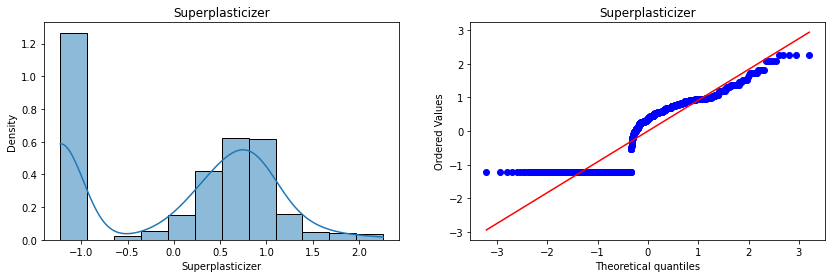

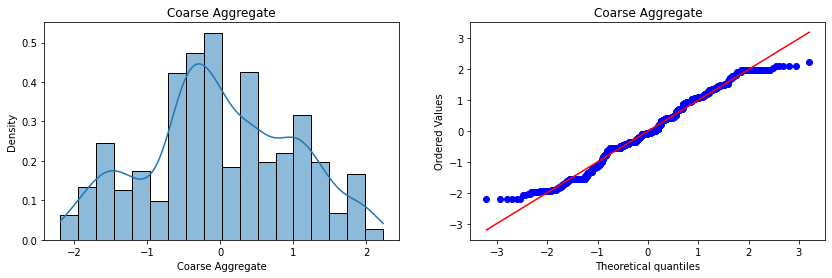

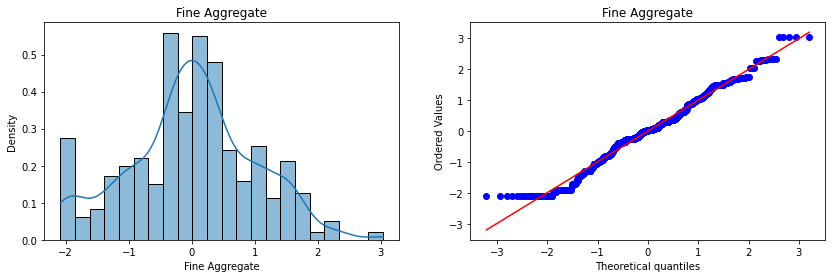

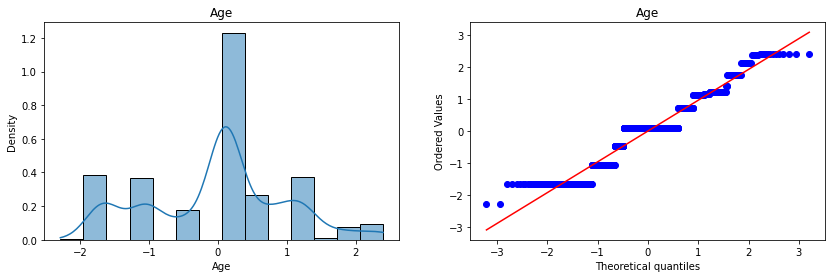

In [77]:
for column in x.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    sns.histplot(x_yeo_johnson_dataset[column],stat="density",kde=True)
    plt.title(column)
    plt.subplot(1,2,2)
    stats.probplot(x_yeo_johnson_dataset[column],dist="norm",plot=plt)
    plt.title(column)

In [79]:
pd.DataFrame({"columns":x.columns,"yeo_johnson_lambdas":pt.lambdas_})

,columns,yeo_johnson_lambdas
0,Cement,0.169544
1,Blast Furnace Slag,0.016633
2,Fly Ash,-0.136480
3,Water,0.808438
4,Superplasticizer,0.264160
5,Coarse Aggregate,1.129395
6,Fine Aggregate,1.830763
7,Age,0.001771
